In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import SparsePCA, PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Sparse PCA sur Wholesale Customers

Objectif: apprendre une representation parcimonieuse des depenses clients (6 variables de montant), avec selection d'hyperparametre sur validation.

## Metriques suivies
- `val_reconstruction_mse`: erreur de reconstruction sur le jeu de validation (plus petit = meilleur).
- `component_sparsity`: proportion de coefficients exactement nuls dans les composantes (plus grand = plus interpretable).

In [2]:
# 1) Chargement du dataset Wholesale Customers
urls = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv",
    "https://raw.githubusercontent.com/selva86/datasets/master/Wholesale%20customers%20data.csv",
]

df = None
for url in urls:
    try:
        df = pd.read_csv(url)
        break
    except Exception:
        pass

if df is None:
    try:
        df = pd.read_csv("Wholesale customers data.csv")
    except Exception as exc:
        raise RuntimeError(
            "Impossible de charger le dataset. Verifie la connexion Internet "
            "ou place 'Wholesale customers data.csv' dans ce dossier."
        ) from exc

print(f"Dataset shape: {df.shape}")
print("Columns:", list(df.columns))

feature_cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen",
]
X = df[feature_cols].copy()
X.head()

Dataset shape: (440, 8)
Columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## Decoupage des donnees
On fait un split explicite `train/validation/test = 60/20/20`, puis une standardisation sur `train` uniquement.

In [3]:
# 2) Split train / val / test + standardisation
X_train, X_temp = train_test_split(X, test_size=0.4, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, "| Val:", X_val_s.shape, "| Test:", X_test_s.shape)

Train: (264, 6) | Val: (88, 6) | Test: (88, 6)


## Selection d'hyperparametre (alpha)

On choisit `alpha` sur le jeu de validation.

- Plus `alpha` est grand, plus les composantes deviennent parcimonieuses.
- Trop grand peut degrader la reconstruction.

In [4]:
# 3) Selection de alpha sur validation
n_components = 3
alpha_grid = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]

results = []
for alpha in alpha_grid:
    spca = SparsePCA(
        n_components=n_components,
        alpha=alpha,
        ridge_alpha=0.01,
        random_state=42,
        max_iter=2000,
    )
    spca.fit(X_train_s)

    Z_val = spca.transform(X_val_s)
    X_val_rec = Z_val @ spca.components_
    if hasattr(spca, "mean_"):
        X_val_rec += spca.mean_

    val_mse = mean_squared_error(X_val_s, X_val_rec)
    sparsity = np.mean(np.isclose(spca.components_, 0.0))

    results.append(
        {
            "alpha": alpha,
            "val_reconstruction_mse": val_mse,
            "component_sparsity": sparsity,
        }
    )

results_df = pd.DataFrame(results).sort_values("val_reconstruction_mse")
display(results_df)

best_alpha = float(results_df.iloc[0]["alpha"])
print(f"Best alpha: {best_alpha}")

,alpha,val_reconstruction_mse,component_sparsity
0,0.1,0.162101,0.277778
1,0.3,0.163477,0.333333
2,0.5,0.164961,0.333333
3,1.0,0.167197,0.444444
4,2.0,0.171065,0.611111
5,5.0,0.171535,0.666667


Best alpha: 0.1


## Entrainement final et evaluation

On refit le modele avec `train + validation`, puis on evalue sur `test`.

Comparaison avec une PCA classique:
- `test_mse_spca` vs `test_mse_pca`

In [5]:
# 4) Refit sur train+val puis evaluation test
X_trainval_s = np.vstack([X_train_s, X_val_s])

best_spca = SparsePCA(
    n_components=n_components,
    alpha=best_alpha,
    ridge_alpha=0.01,
    random_state=42,
    max_iter=2000,
)
best_spca.fit(X_trainval_s)

Z_test = best_spca.transform(X_test_s)
X_test_rec = Z_test @ best_spca.components_
if hasattr(best_spca, "mean_"):
    X_test_rec += best_spca.mean_

test_mse_spca = mean_squared_error(X_test_s, X_test_rec)

pca = PCA(n_components=n_components, random_state=42)
pca.fit(X_trainval_s)
X_test_rec_pca = pca.inverse_transform(pca.transform(X_test_s))
test_mse_pca = mean_squared_error(X_test_s, X_test_rec_pca)

print(f"Sparse PCA test reconstruction MSE: {test_mse_spca:.4f}")
print(f"Classical PCA test reconstruction MSE: {test_mse_pca:.4f}")

Sparse PCA test reconstruction MSE: 0.1840
Classical PCA test reconstruction MSE: 0.1880


Sparse PCA loadings:


,SPC1,SPC2,SPC3
Fresh,0.000000,0.000000,0.996434
Milk,0.535234,0.178933,0.048265
Grocery,0.594704,0.000000,0.000000
Frozen,-0.007731,0.808576,0.052904
Detergents_Paper,0.570862,-0.076214,-0.044618
Delicassen,0.184142,0.555319,0.000000


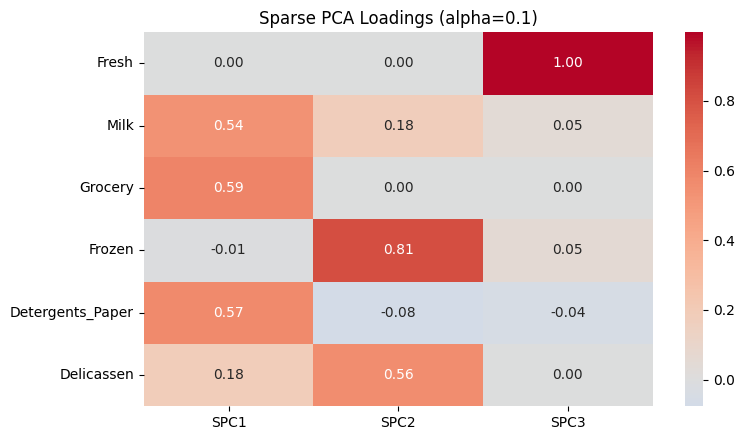

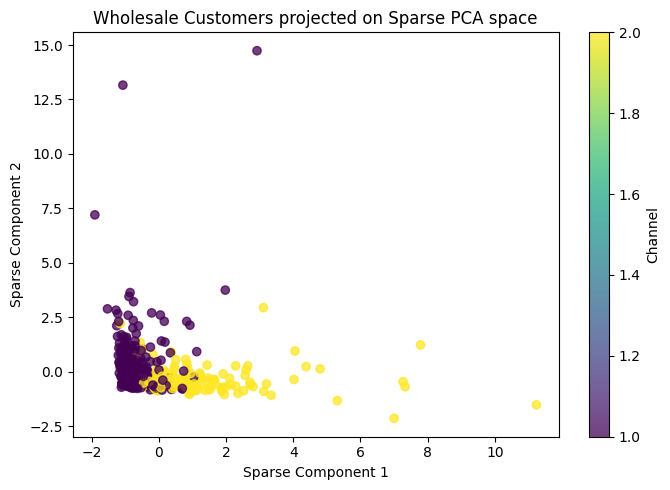

In [7]:
# 5) Loadings Sparse PCA + visualisations
loadings = pd.DataFrame(
    best_spca.components_.T,
    index=feature_cols,
    columns=[f"SPC{i+1}" for i in range(n_components)],
)

print("Sparse PCA loadings:")
display(loadings)

plt.figure(figsize=(8, 4.5))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title(f"Sparse PCA Loadings (alpha={best_alpha})")
plt.tight_layout()
plt.show()

Z_all = best_spca.transform(scaler.transform(X))

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    Z_all[:, 0],
    Z_all[:, 1],
    c=df["Channel"],
    cmap="viridis",
    alpha=0.75,
)
plt.colorbar(scatter, label="Channel")
plt.xlabel("Sparse Component 1")
plt.ylabel("Sparse Component 2")
plt.title("Wholesale Customers projected on Sparse PCA space")
plt.tight_layout()
plt.show()

In [8]:
# 7) Resume ultra-compact des metriques
mini_metrics_df = pd.DataFrame(
    {
        "metric": [
            "MSE (test)",
            "Silhouette (true labels)",
            "Sparsity (SPCA)",
        ],
        "SPCA": [
            float(test_mse_spca),
            float(sil_true_spca),
            float(sparsity_ratio),
        ],
    }
)

display(mini_metrics_df)



,metric,SPCA
0,MSE (test),0.184034
1,Silhouette (true labels),0.268904
2,Sparsity (SPCA),0.277778
